# Comparison Againts Baseline

In [1]:
def default_params(): 
    return {
        'current_model': 'M1', 
        'quantization': 'none', #['none',"int4", "int8", "float32", "float16"]
        'propensity_threshold': 0.5,
        'psc_column': 'code_smell_psc_relative', #code_smell_actual_prob_median, #code_smell_max_prob_median, #code_smell_min_prob_median, #code_smell_actual_prob_mean, #code_smell_max_prob_mean, #code_smell_min_prob_mean, #code_smell_psc_entropy, #code_smell_psc_relative  
        'psc_distributions_conditioned_file' : '/workspaces/CodeSmells/data/extension/transformation/alignments/M1_q_none/curated/aligned_smells.json',
        'decoding_strategy': 'sampling', #['curated','greedy_search', 'beam_search', 'sampling', 'contrastive_search', 'top_k_sampling', 'top_p_sampling'],
        'alignments_path': '/workspaces/CodeSmells/data/extension/generation/alignments',
        'output_path': '/workspaces/CodeSmells/data/extension/baselines',
        'cache_dir': '/workspaces/CodeSmells/datax/hugging_face_cache',
    }
params = default_params()


### Imports

In [2]:
import pandas as pd
from codebleu import calc_codebleu
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import statistics as stats
import os

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [3]:
### GENERATED
psc_distributions_unconditioned_df = pd.read_json(f"{params['alignments_path']}/{params['current_model']}_q_{params['quantization']}/{params['decoding_strategy']}/aligned_smells.json")

### GROUND TRUTH
psc_distributions_conditioned_df = pd.read_json(params['psc_distributions_conditioned_file'])

In [4]:
psc_distributions_conditioned_df.columns

Index(['id', 'commit_id', 'repo', 'path', 'file_name', 'fun_name',
       'commit_message', 'code', 'url', 'language', 'ast_errors',
       'n_ast_errors', 'ast_levels', 'n_whitespaces', 'n_words', 'vocab_size',
       'complexity', 'nloc', 'token_counts', 'n_ast_nodes', 'n_identifiers',
       's_msg_id', 's_line', 's_column', 's_end_line', 's_end_column',
       's_code', 'category', 'input_lenght', 'input_ids', 'max_prob',
       'min_prob', 'actual_prob', 'loss', 'code_smell_pos',
       'code_smell_actual_logits', 'code_smell_max_logits',
       'code_smell_min_logits', 'code_smell_actual_prob_median',
       'code_smell_max_prob_median', 'code_smell_min_prob_median',
       'code_smell_actual_prob_mean', 'code_smell_max_prob_mean',
       'code_smell_min_prob_mean', 'code_smell_psc_entropy',
       'code_smell_psc_relative'],
      dtype='object')

### Baselines Computation

In [5]:
def calculate_code_smell_proportion(psc_distributions_conditioned_df, psc_distributions_unconditioned_df, target_smell_id=None):
    conditioned_df = psc_distributions_conditioned_df.copy()
    unconditioned_df = psc_distributions_unconditioned_df.copy()
    # Filter unconditioned DataFrame by target smell ID if specified
    if target_smell_id is not None:
        unconditioned_df = unconditioned_df[unconditioned_df['s_msg_id'] == target_smell_id]
        conditioned_df = conditioned_df[conditioned_df['s_msg_id'] == target_smell_id]

    # Extract IDs for comparison
    matching_ids = sorted(unconditioned_df[unconditioned_df['id'].isin(conditioned_df['id'])]['id'].tolist())
    total_conditioned_ids = sorted(conditioned_df['id'].tolist())

    # Remove duplicates
    matching_ids = list(set(matching_ids))
    total_conditioned_ids = list(set(total_conditioned_ids))

    # Calculate the proportion of matching IDs
    proportion = len(matching_ids) / len(total_conditioned_ids) if total_conditioned_ids else 0

    return proportion

In [6]:
def compute_codebleu_score(psc_distributions_conditioned_df, psc_distributions_unconditioned_df, target_smell_id=None):
    try:
        conditioned_df = psc_distributions_conditioned_df.copy()
        unconditioned_df = psc_distributions_unconditioned_df.copy()
        # Filter unconditioned DataFrame by target smell ID if specified
        if target_smell_id is not None:
            unconditioned_df = unconditioned_df[unconditioned_df['s_msg_id'] == target_smell_id]
            conditioned_df = conditioned_df[conditioned_df['s_msg_id'] == target_smell_id]

        # Sort both DataFrames by ID for alignment
        conditioned_df = conditioned_df.sort_values(by='id')
        unconditioned_df = unconditioned_df.sort_values(by='id')

        # Keep only matching IDs
        matching_ids = unconditioned_df['id'].isin(conditioned_df['id'])
        filtered_unconditioned_df = unconditioned_df[matching_ids]

        # Ensure alignment by merging on ID
        aligned_df = filtered_unconditioned_df.merge(conditioned_df[['id', 'code']], on='id', suffixes=('_predicted', '_groundtruth'))

        # Extract code lists
        predicted_codes = aligned_df['code_predicted'].tolist()
        groundtruth_codes = aligned_df['code_groundtruth'].tolist()

    # Compute CodeBLEU score
    
        codebleu_score = calc_codebleu(groundtruth_codes, predicted_codes, lang='python')
    except Exception as e:
        print(f"Error calculating CodeBLEU score: {e}")
        codebleu_score = 0.0
    codebleu_score = calc_codebleu(groundtruth_codes, predicted_codes, lang='python')
    
    return codebleu_score

In [7]:
def compute_average_bleu_score(psc_distributions_conditioned_df, psc_distributions_unconditioned_df, target_smell_id=None):
    conditioned_df = psc_distributions_conditioned_df.copy()
    unconditioned_df = psc_distributions_unconditioned_df.copy()
    # Filter unconditioned DataFrame by target smell ID if specified
    if target_smell_id is not None:
        unconditioned_df = unconditioned_df[unconditioned_df['s_msg_id'] == target_smell_id]
        conditioned_df = conditioned_df[conditioned_df['s_msg_id'] == target_smell_id]

    # Align both DataFrames by 'id'
    conditioned_df = conditioned_df.sort_values(by='id')
    unconditioned_df = unconditioned_df.sort_values(by='id')

    matching_predictions = unconditioned_df[unconditioned_df['id'].isin(conditioned_df['id'])]
    aligned_df = matching_predictions.merge(
        conditioned_df[['id', 'code']], on='id', suffixes=('_predicted', '_reference')
    )

    predicted_snippets = aligned_df['code_predicted'].tolist()
    reference_snippets = aligned_df['code_reference'].tolist()

    # BLEU setup
    smoother = SmoothingFunction().method1
    bleu_scores = []

    for reference_code, predicted_code in zip(reference_snippets, predicted_snippets):
        ref_tokens = reference_code.split()
        pred_tokens = predicted_code.split()
        score = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smoother)
        bleu_scores.append(score)

    return sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0.0


### Compute global PSC Score

In [8]:
def compute_global_psc(psc_distributions_conditioned_df, score_name, estimand, target_smell_id=None):
    conditioned_df = psc_distributions_conditioned_df.copy()
    # Filter unconditioned DataFrame by target smell ID if specified
    if target_smell_id is not None:
        conditioned_df = conditioned_df[conditioned_df['s_msg_id'] == target_smell_id]
    # Compute the statistical estimand on the specified column
    estimand_value = estimand(conditioned_df[score_name])
    return estimand_value

### Create Comparison DF

In [16]:
def compute_scores_df(conditioned_df, unconditioned_df):
    results = []

    for smell_id in conditioned_df['s_msg_id'].unique():
        if smell_id not in unconditioned_df['s_msg_id'].unique():
            print(f"Target smell ID {smell_id} not found in unconditioned DataFrame.")
            continue

        result_row = {
            's_msg_id': smell_id,
            'proportion': calculate_code_smell_proportion(conditioned_df, unconditioned_df, smell_id),
            'codebleu': compute_codebleu_score(conditioned_df, unconditioned_df, smell_id)['codebleu'],
            'average_bleu': compute_average_bleu_score(conditioned_df, unconditioned_df, smell_id),
            'median_psc': compute_global_psc(conditioned_df, params['psc_column'], stats.median, smell_id),
            'mean_psc': compute_global_psc(conditioned_df, params['psc_column'], stats.mean, smell_id),
            'max_psc': compute_global_psc(conditioned_df, params['psc_column'], max, smell_id),
            'min_psc': compute_global_psc(conditioned_df, params['psc_column'], min, smell_id),
        }

        results.append(result_row)

    return pd.DataFrame(results)


### Execute Analysis

In [17]:
results_df = compute_scores_df(psc_distributions_conditioned_df, psc_distributions_unconditioned_df)

### Save

In [18]:
def create_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)

In [19]:
output_dir = f"{params['output_path']}/{params['current_model']}_q_{params['quantization']}"
create_folder(output_dir)
results_df.to_json(f"{output_dir}/{params['psc_column']}_{params['decoding_strategy']}_comparison.json")

### Analyze results

In [20]:
results_df

,s_msg_id,proportion,codebleu,average_bleu,median_psc,mean_psc,max_psc,min_psc
0,W0311,0.028000,0.617036,0.491514,0.819332,0.797467,1.000000,0.131011
1,C0301,0.102823,0.598505,0.420561,0.829978,0.803351,1.000000,0.362013
2,C0303,0.072000,0.536306,0.301579,0.002150,0.087261,1.000000,0.000014
3,C0415,0.126033,0.581351,0.441992,0.718725,0.714078,1.000000,0.000001
4,W0212,0.105906,0.598463,0.407138,0.804839,0.772102,1.000000,0.000007
5,W0612,0.070686,0.521032,0.421898,0.654900,0.595809,1.000000,0.000002
6,C0114,0.026000,0.539051,0.255121,0.536518,0.531266,0.849390,0.092121
7,W0613,0.060000,0.553823,0.259303,0.687276,0.636817,1.000000,0.000017
8,C0116,0.028000,0.540015,0.257945,0.357195,0.331261,0.689366,0.000512
9,C0304,0.024000,0.532391,0.291172,0.695317,0.706751,1.000000,0.254266


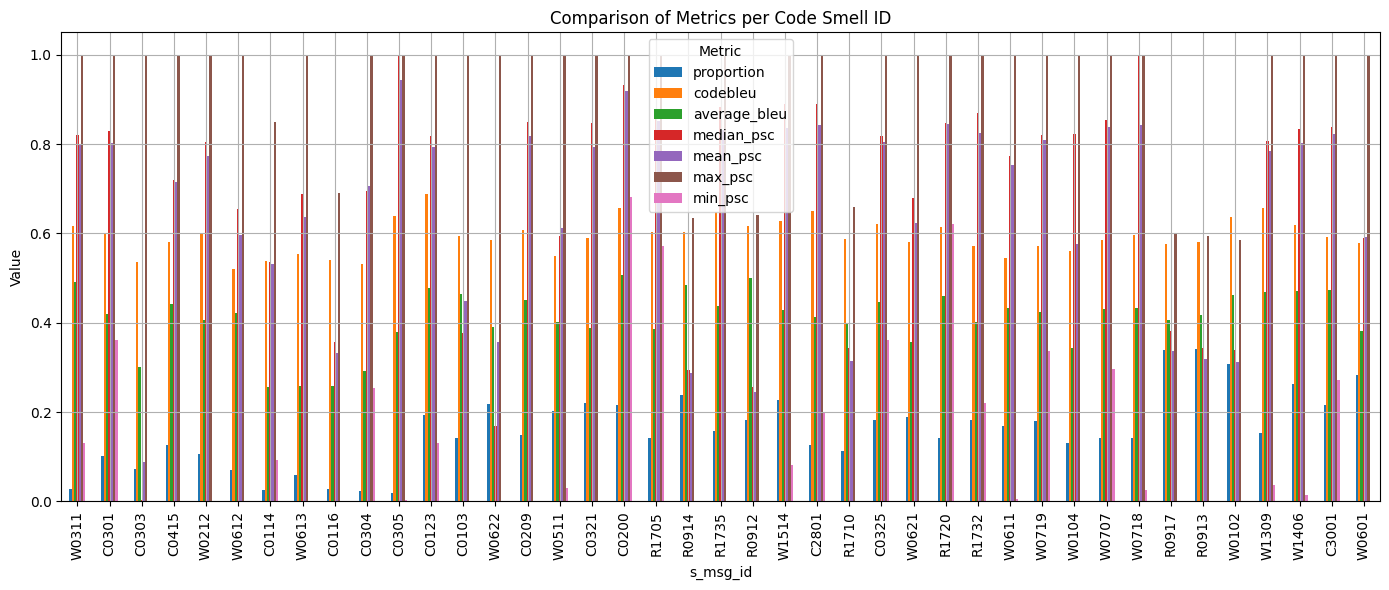

In [ ]:
# Create grouped bar plot
ax = results_df.plot(kind='bar', figsize=(14, 6))
plt.title('Comparison of Metrics per Code Smell ID')
plt.ylabel('Value')
plt.xlabel('s_msg_id')
plt.xticks(ticks=range(len(results_df)), labels=results_df['s_msg_id'], rotation=90)
plt.legend(title='Metric')
plt.tight_layout()
plt.grid(True)
plt.show()

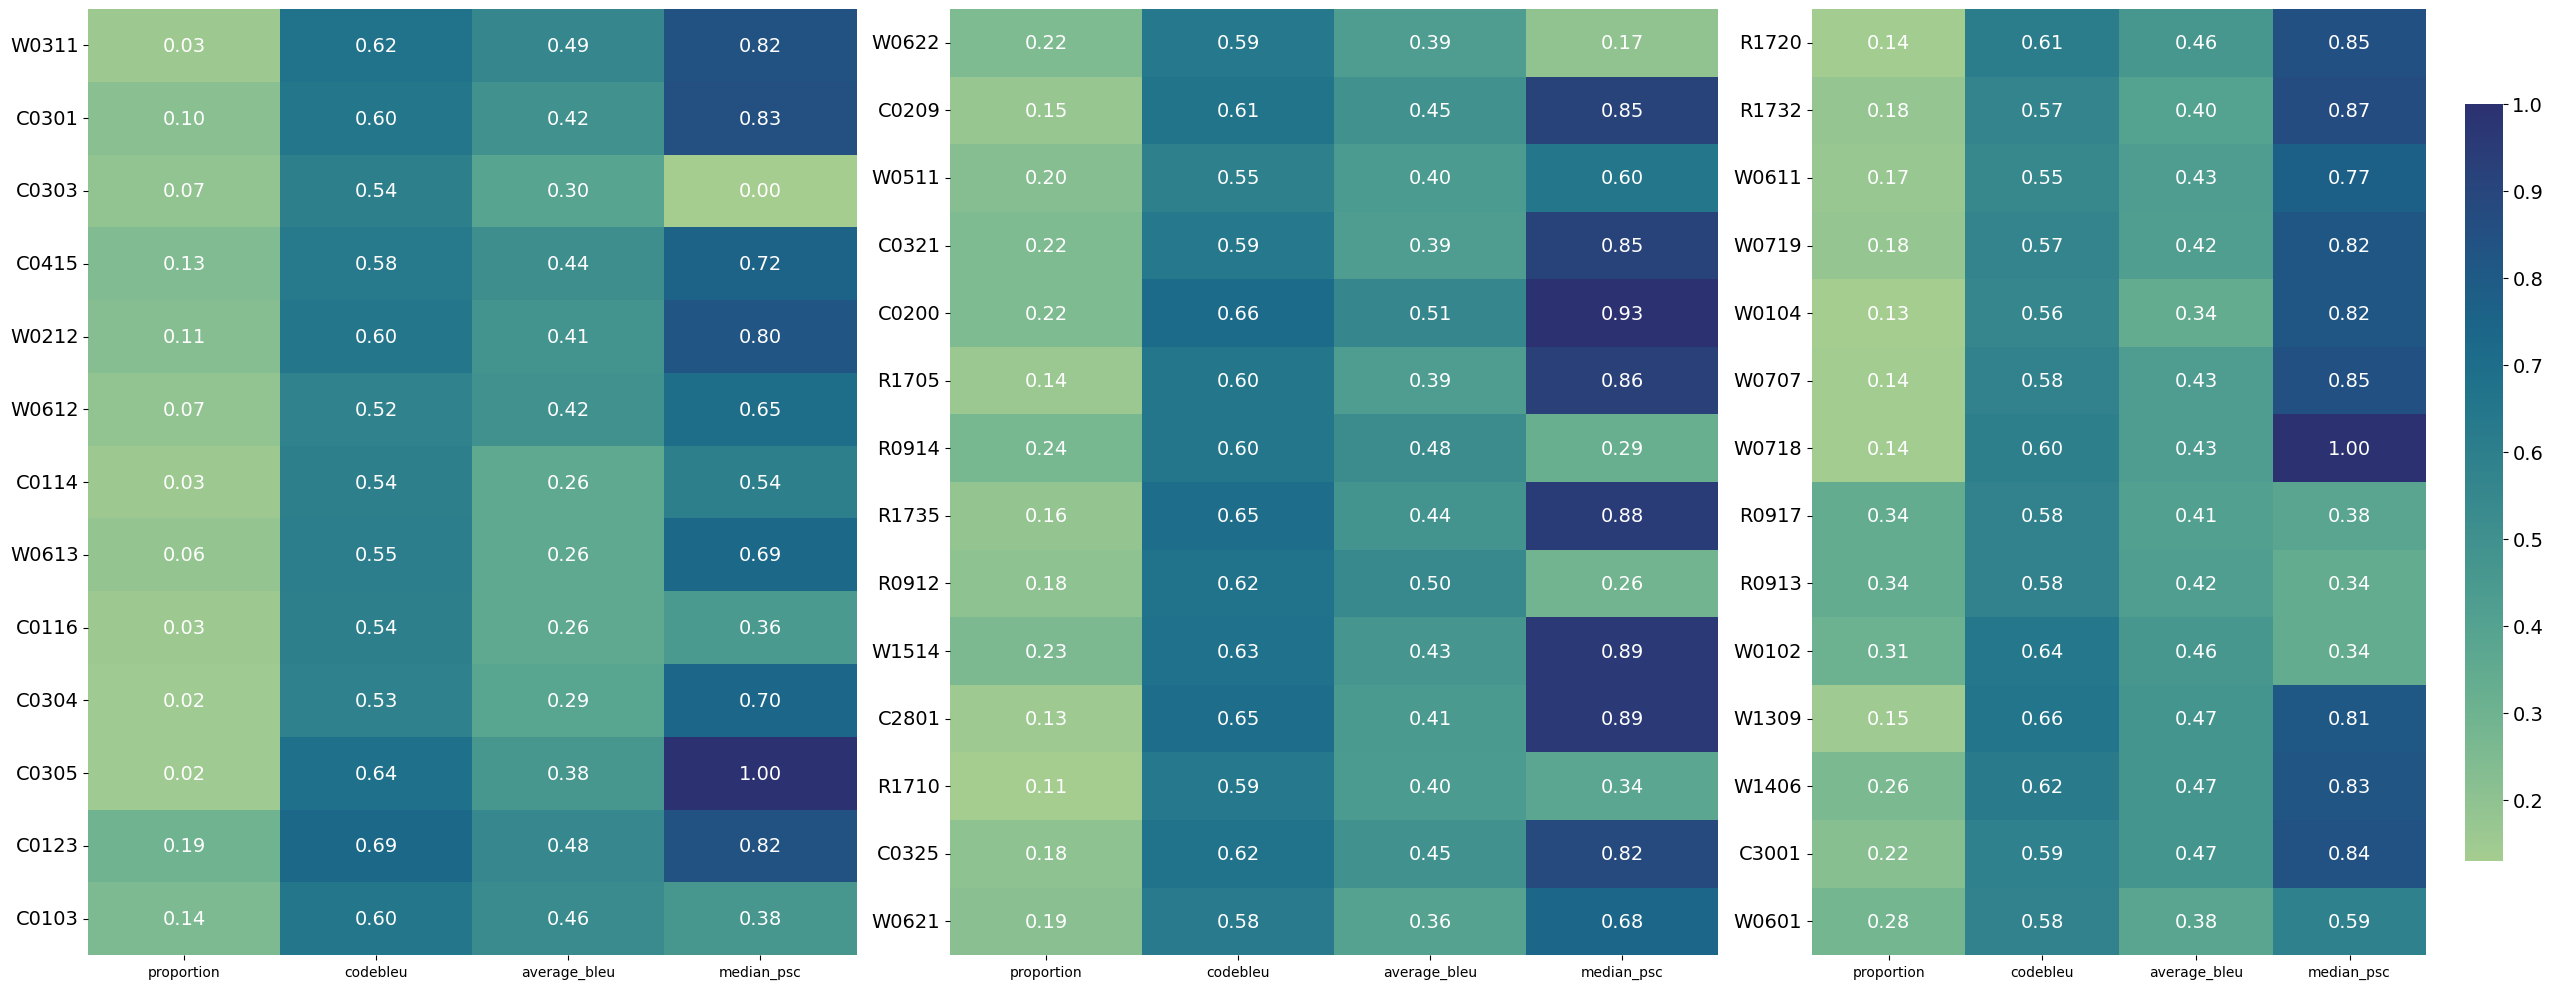

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select relevant metrics and set index
metrics = ['proportion', 'codebleu', 'average_bleu', 'median_psc']
df_values = results_df.set_index('s_msg_id')[metrics]

# Split into three equal parts
n = len(df_values)
splits = [df_values.iloc[i * n // 3: (i + 1) * n // 3] for i in range(3)]
titles = ["Code Smell Metrics - Part 1", "Part 2", "Part 3"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(26, 10))

# Plot each heatmap
for i, (df_part, title) in enumerate(zip(splits, titles)):
    show_colorbar = (i == 2)  # Show colorbar only on the last subplot
    heatmap = sns.heatmap(
        df_part.round(2),
        annot=True,
        fmt=".2f",
        cmap="crest",
        annot_kws={"size": 14, "color": "white"},
        cbar=show_colorbar,
        cbar_kws={"shrink": 0.8} if show_colorbar else None,
        ax=axes[i]
    )
    axes[i].tick_params(axis='y', labelsize=14)
    axes[i].set_yticklabels(axes[i].get_yticklabels(), rotation=0)
    axes[i].set_ylabel("")

    # If colorbar is shown, increase its label font size
    if show_colorbar:
        heatmap.collections[0].colorbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()
